In [1]:
import torch
import torch.nn as nn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

from module import Architecture

from module.Trainner import Trainner
from module.DataLoader import DataLoader

In [2]:
data = DataLoader(path="./data/ANN", type="EMNIST", batch=64)
ANN_architecture = Architecture.ANN(input=28*28, hidden_size=[128, 64, 32], output=47)

train, test = data.Loader()
test_data, test_labels = data.extract(test)

In [3]:
ANNTrain = Trainner(ANN_architecture, "adam", 1e-3, nn.CrossEntropyLoss())
ANNTrain.fit(train, epochs=5, verbose=True)

Epoch 1/5 - Loss: 1.3543 - Accuracy: 60.8839
Epoch 2/5 - Loss: 0.7651 - Accuracy: 76.0824
Epoch 3/5 - Loss: 0.6374 - Accuracy: 79.6161
Epoch 4/5 - Loss: 0.5702 - Accuracy: 81.3103
Epoch 5/5 - Loss: 0.5274 - Accuracy: 82.5133


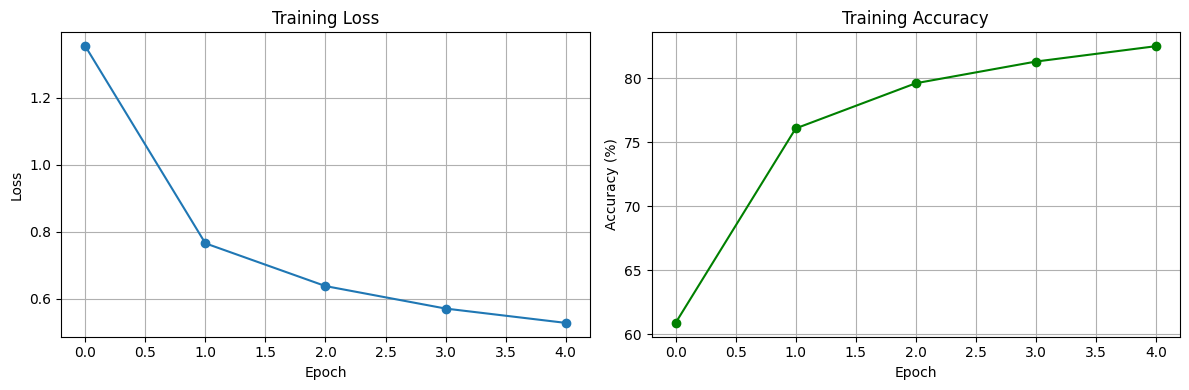

In [5]:
loss, accuracy = ANNTrain.loss_history, ANNTrain.accuracy_history

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(loss, marker='o')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training Loss')
ax1.grid()

ax2.plot(accuracy, marker='o', color='green')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Training Accuracy')
ax2.grid()

plt.tight_layout()
plt.show()

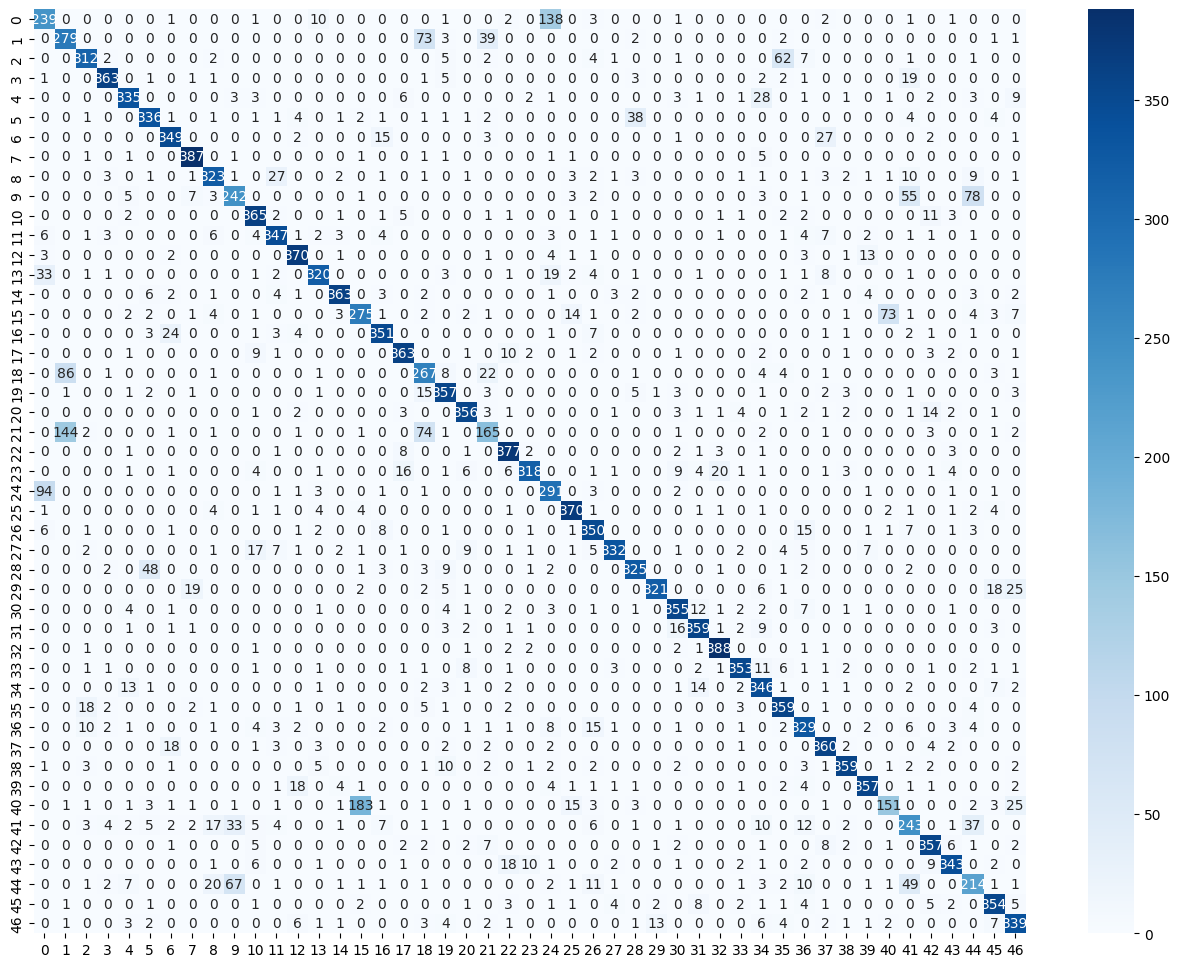

In [4]:
test_accuracy, prediction, true_labels, x_test = ANNTrain.evaluate(test)

cm = confusion_matrix(true_labels, prediction)

plt.figure(figsize=(16, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.show()